In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import json
import pickle
import argparse
import warnings

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [6]:
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
WEATHER = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
WIND_DIR_COL = "wd"
NUMERIC_COLS = POLLUTANTS + WEATHER
TARGET = ["PM2.5"]

In [7]:
INPUT_LEN = 24
OUTPUT_LEN = 24

In [8]:
TRAIN_END = "2015-12-31 23:00:00"
VAL_END = "2016-12-31 23:00:00"

# Test is Rest after validation

In [47]:
data_dir = "datasets/raw_data"
reports_dir = "eda_reports"
output_dir = "datasets/processed_data"

# Loading the datasets

In [10]:
files = sorted(glob.glob(os.path.join(data_dir, "*.csv")))

dfs = []
for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all dataframes
df = pd.concat(dfs, ignore_index=True)

df["datetime"] = pd.to_datetime(df[["year","month", "day", "hour"]])

df = df.drop(columns=["No", "year", "month", "day", "hour"])

df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

print(f"Datashape: {df.shape}, \n"
      f"Stations: {df['station'].nunique()}, \n",
      f"Time Range: {df['datetime'].min()} to {df['datetime'].max()}")


Datashape: (420768, 14), 
Stations: 12, 
 Time Range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00


# Data Types, Duplicates, Gap & Missing Value analysis

In [11]:
df.dtypes

PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                     str
WSPM               float64
station                str
datetime    datetime64[us]
dtype: object

In [12]:
df.duplicated(subset=["station", "datetime"]).sum()

np.int64(0)

In [13]:
gap_rows = []

for station, g in df.groupby("station"):
    full_range = pd.date_range(start=g["datetime"].min(), end=g["datetime"].max(), freq="h")
    missing_ts = full_range.difference(g["datetime"])
    gap_rows.append((station, len(g), len(full_range), len(missing_ts)))
    print(f"   {station:15s} rows={len(g):6d} expected={len(full_range):6d} "
                  f"missing_timestamps={len(missing_ts)}")

   Aotizhongxin    rows= 35064 expected= 35064 missing_timestamps=0
   Changping       rows= 35064 expected= 35064 missing_timestamps=0
   Dingling        rows= 35064 expected= 35064 missing_timestamps=0
   Dongsi          rows= 35064 expected= 35064 missing_timestamps=0
   Guanyuan        rows= 35064 expected= 35064 missing_timestamps=0
   Gucheng         rows= 35064 expected= 35064 missing_timestamps=0
   Huairou         rows= 35064 expected= 35064 missing_timestamps=0
   Nongzhanguan    rows= 35064 expected= 35064 missing_timestamps=0
   Shunyi          rows= 35064 expected= 35064 missing_timestamps=0
   Tiantan         rows= 35064 expected= 35064 missing_timestamps=0
   Wanliu          rows= 35064 expected= 35064 missing_timestamps=0
   Wanshouxigong   rows= 35064 expected= 35064 missing_timestamps=0


In [14]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

print("Missing Values:\n", pd.concat([missing, missing_percent], axis=1, keys=["count", "percent"]))

Missing Values:
           count  percent
CO        20701     4.92
O3        13277     3.16
NO2       12116     2.88
SO2        9021     2.14
PM2.5      8739     2.08
PM10       6449     1.53
wd         1822     0.43
DEWP        403     0.10
TEMP        398     0.09
PRES        393     0.09
RAIN        390     0.09
WSPM        318     0.08
station       0     0.00
datetime      0     0.00


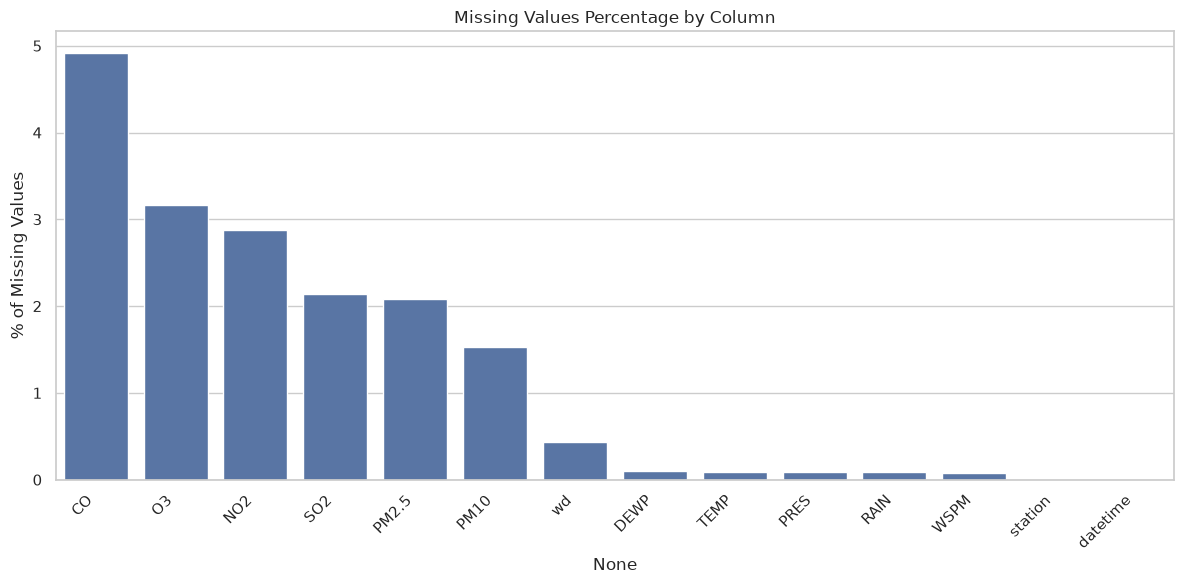

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
missing_val_df = pd.DataFrame({'count': missing, 'percent': missing_percent})
sns.barplot(x=missing_val_df.index, y=missing_val_df['percent'], ax=ax)
ax.set_ylabel("% of Missing Values")
ax.set_title("Missing Values Percentage by Column")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(os.path.join(reports_dir, "missing_values_percentage.png"))

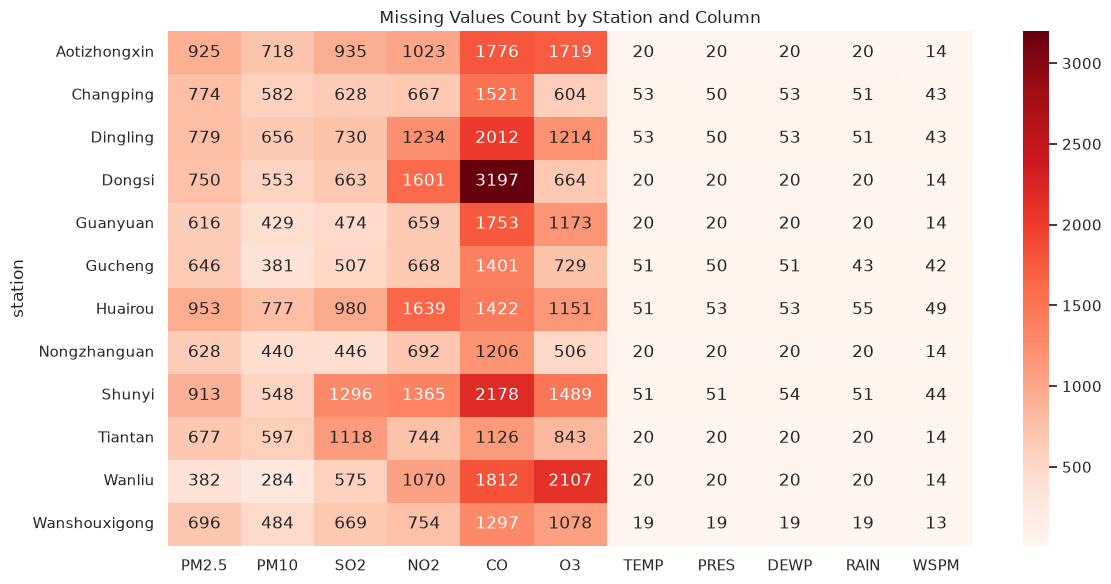

In [16]:
pivot = df.groupby("station")[NUMERIC_COLS].apply(
    lambda g: g.isna().sum()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds", ax=ax)
ax.set_title("Missing Values Count by Station and Column")
plt.tight_layout()
fig.savefig(os.path.join(reports_dir, "missing_values_by_stations.png"))

# Distribution and outliers

In [17]:
df[NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,412029.0,79.793428,80.822391,2.0000,20.0,55.0,111.0,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.0,82.0,145.0,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.0,7.0,20.0,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.0,43.0,71.0,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.0,900.0,1500.0,10000.0
O3,407491.0,57.372271,56.661607,0.2142,11.0,45.0,82.0,1071.0
TEMP,420370.0,13.538976,11.436139,-19.9000,3.1,14.5,23.3,41.6
PRES,420375.0,1010.746982,10.474055,982.4000,1002.3,1010.4,1019.0,1042.8
DEWP,420365.0,2.490822,13.793847,-43.4000,-8.9,3.1,15.1,29.1
RAIN,420378.0,0.064476,0.821004,0.0000,0.0,0.0,0.0,72.5


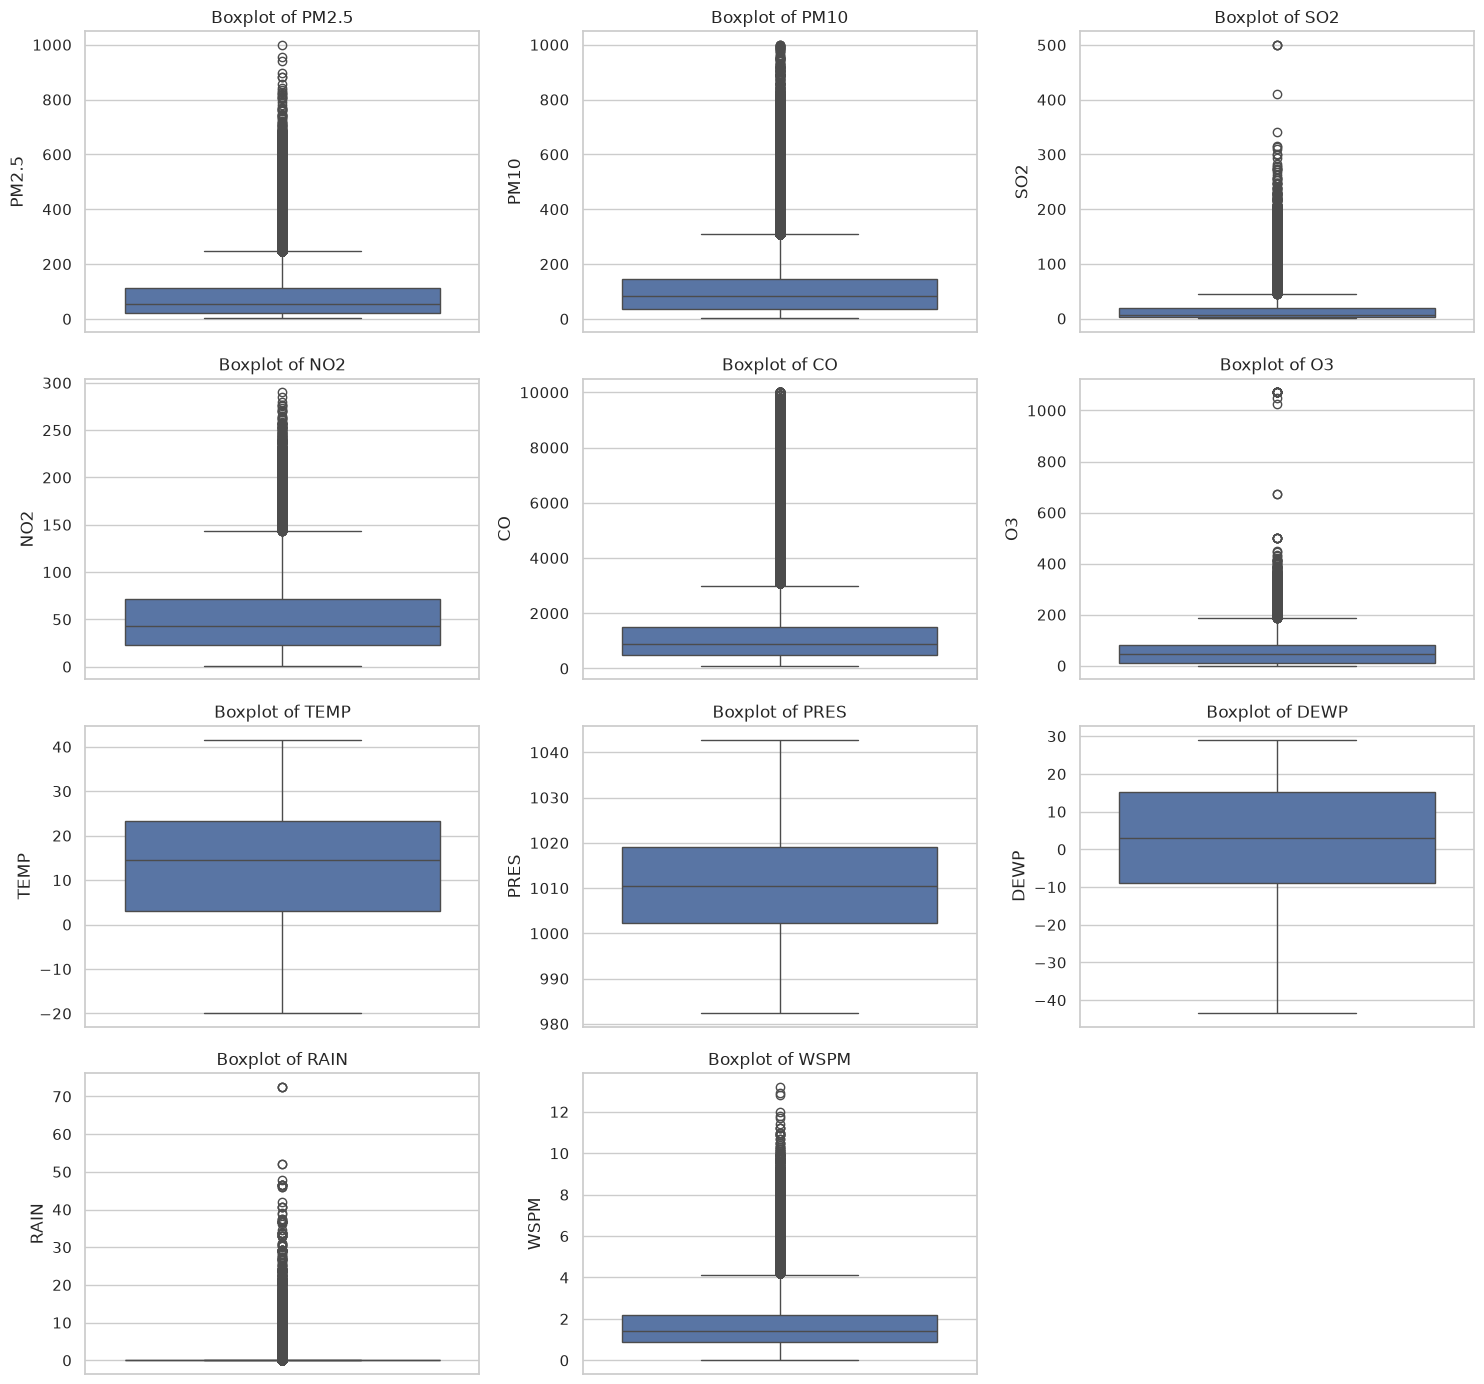

In [18]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")

for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(os.path.join(reports_dir, "boxplots_raw_data.png"))

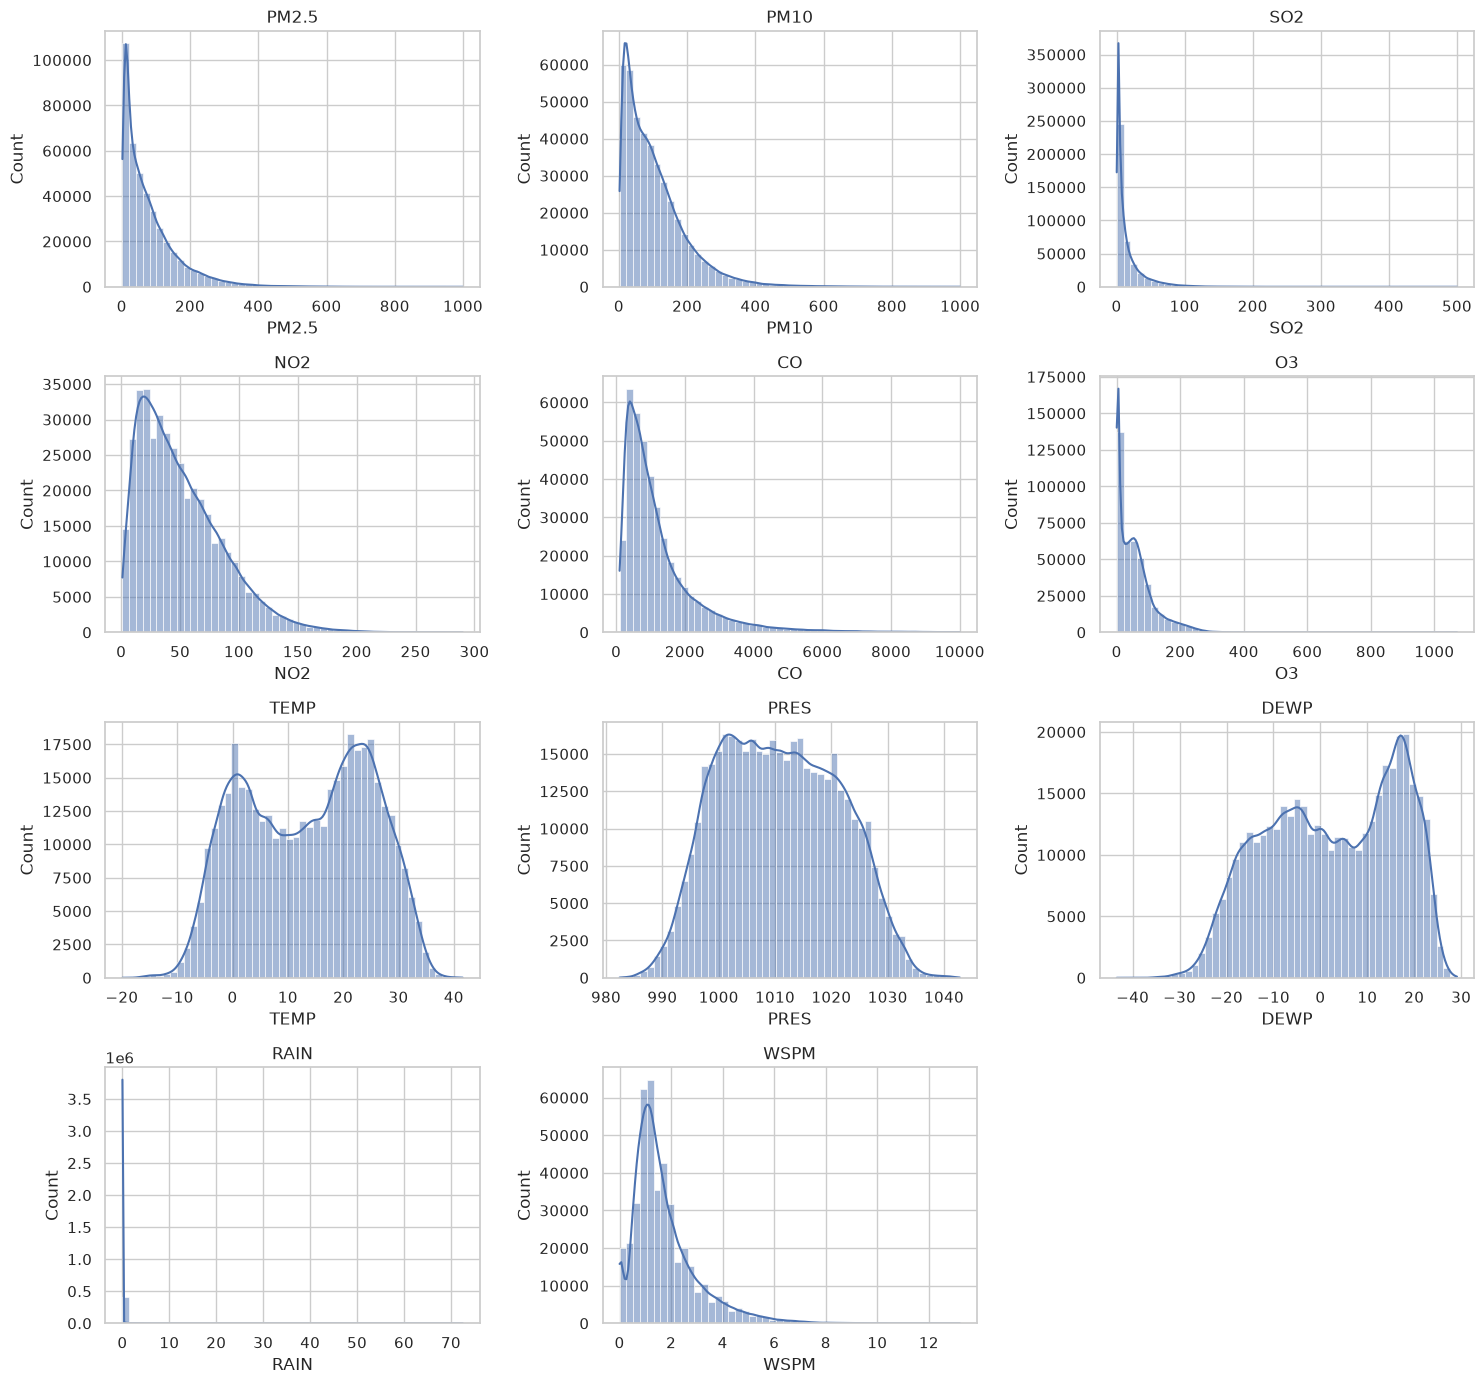

In [19]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=50)
    ax.set_title(col)    
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(os.path.join(reports_dir, "histograms_raw.png"))

# Correlation between features

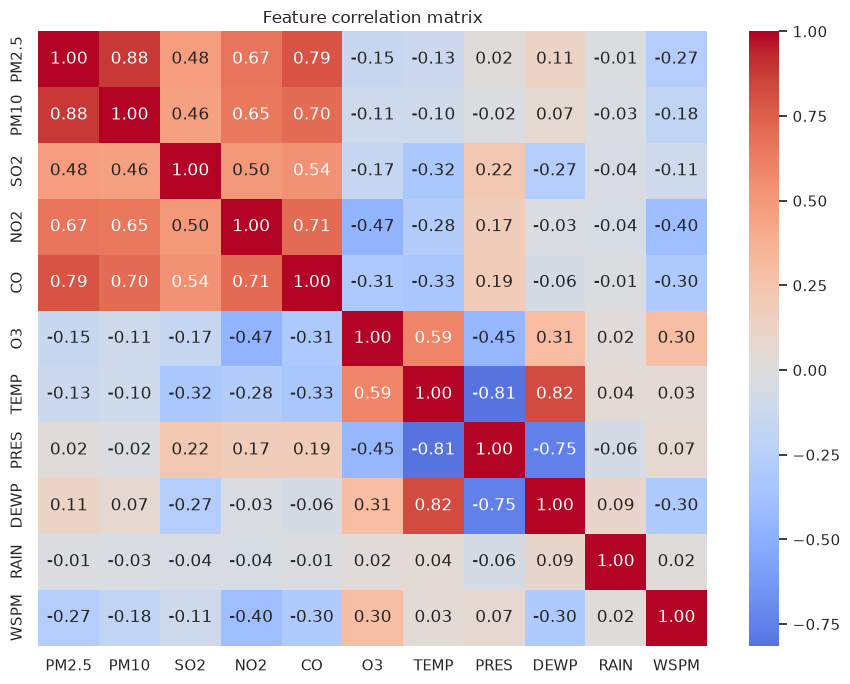

In [20]:
corr = df[NUMERIC_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
fig.savefig(os.path.join(reports_dir, "correlation_matrix.png"))

# Correlation of same features between stations

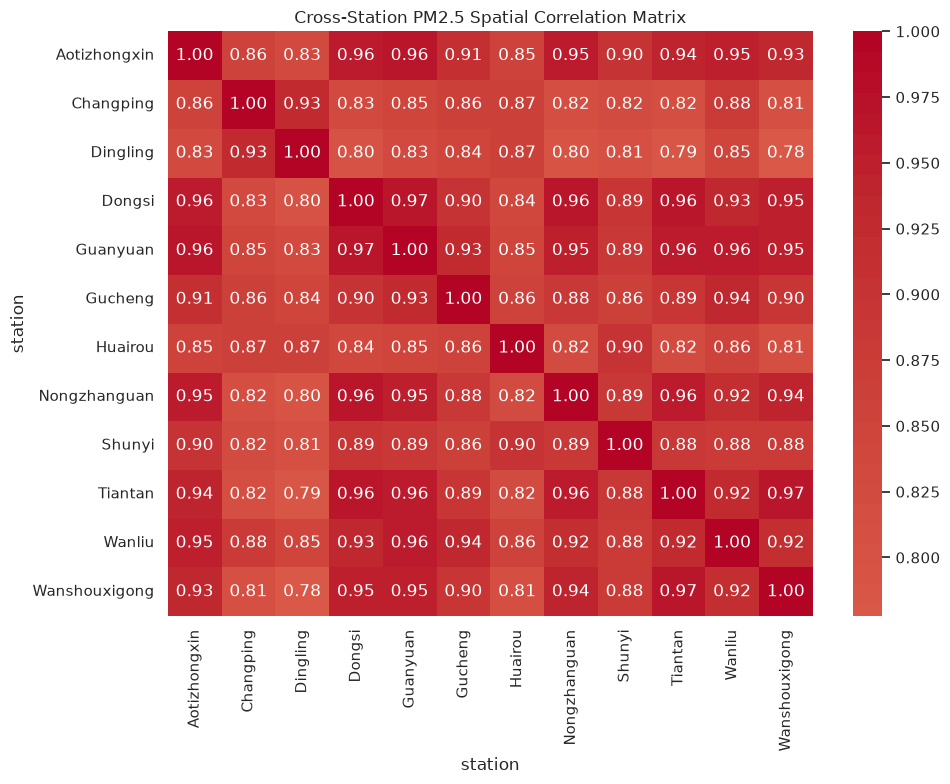

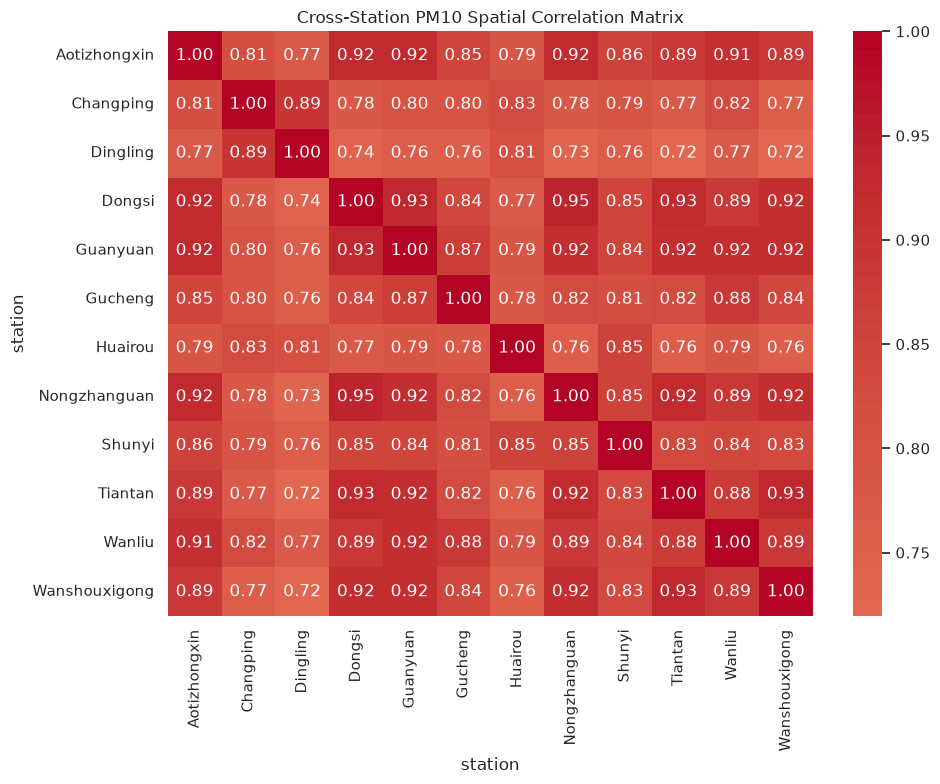

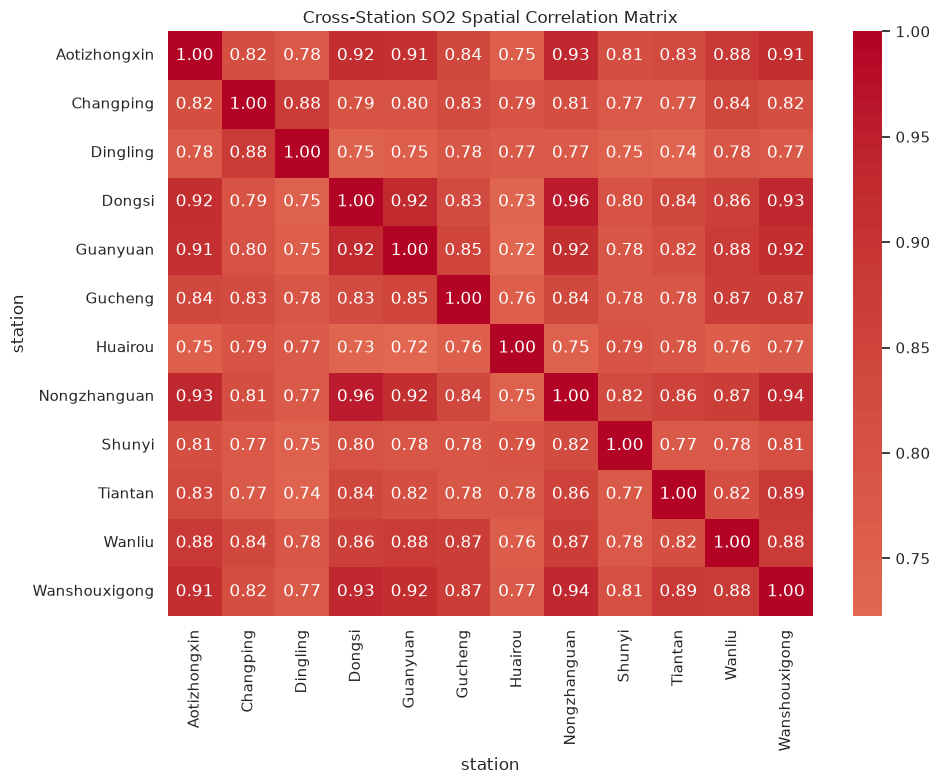

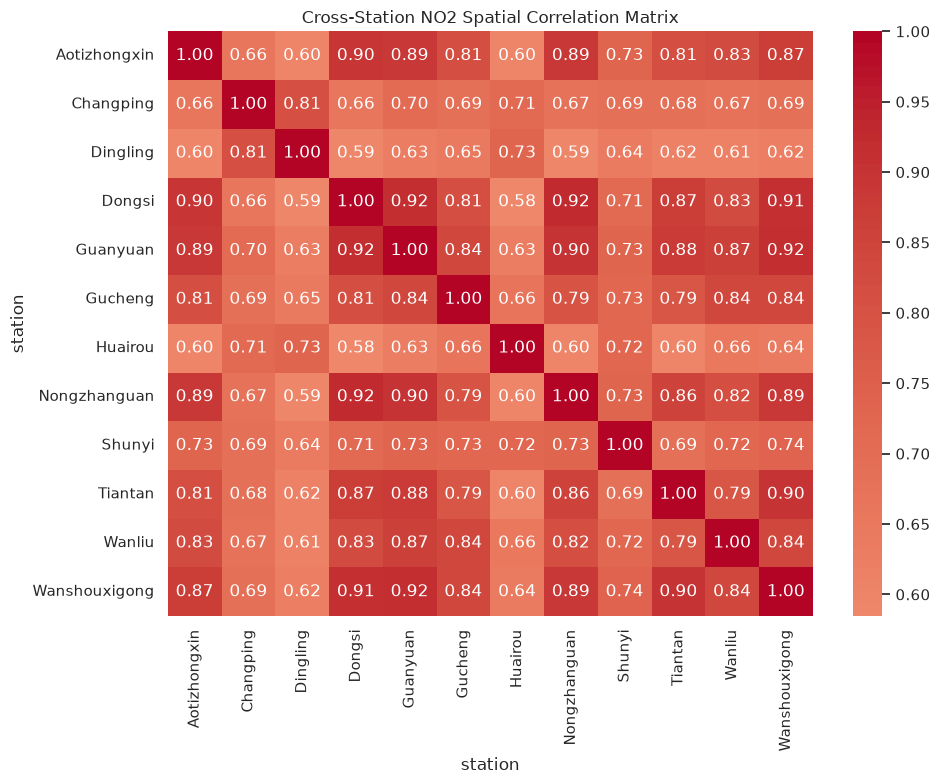

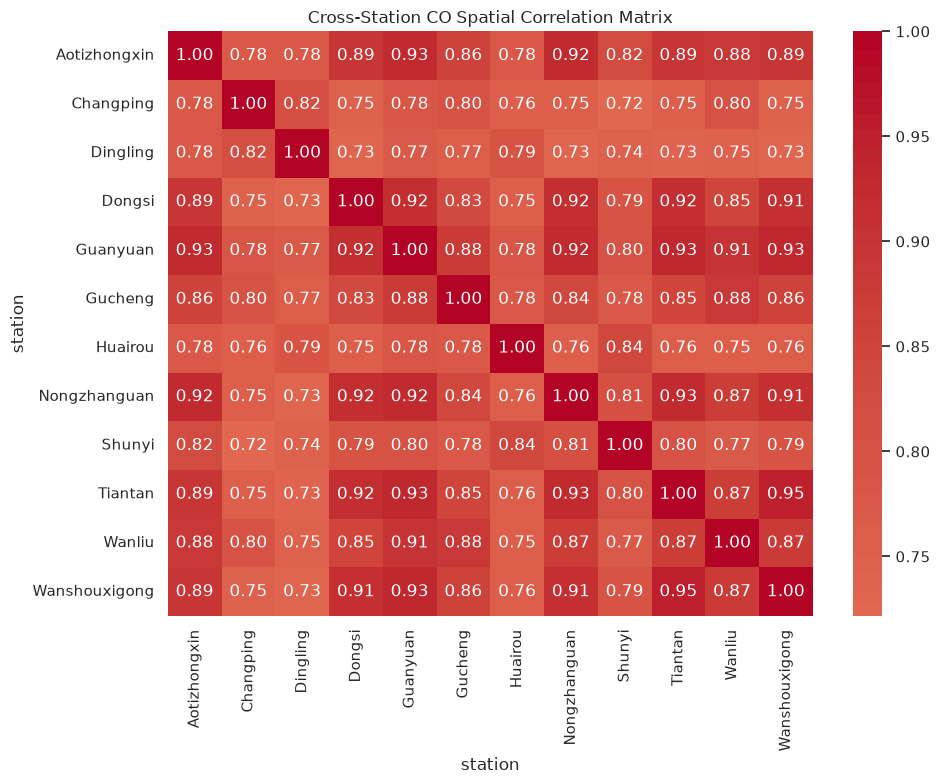

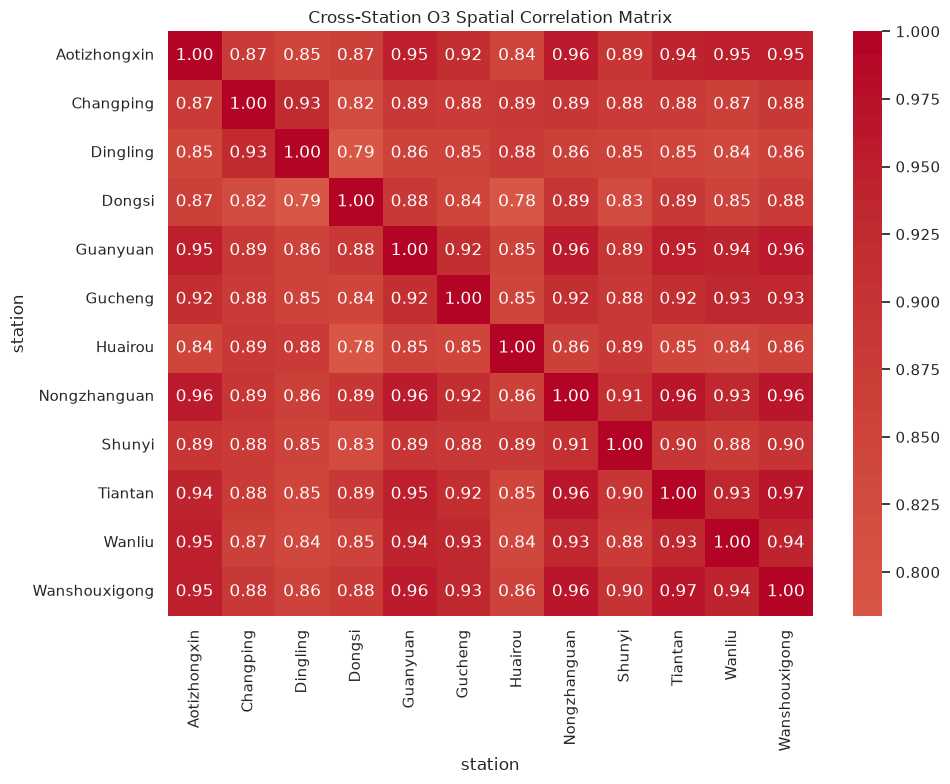

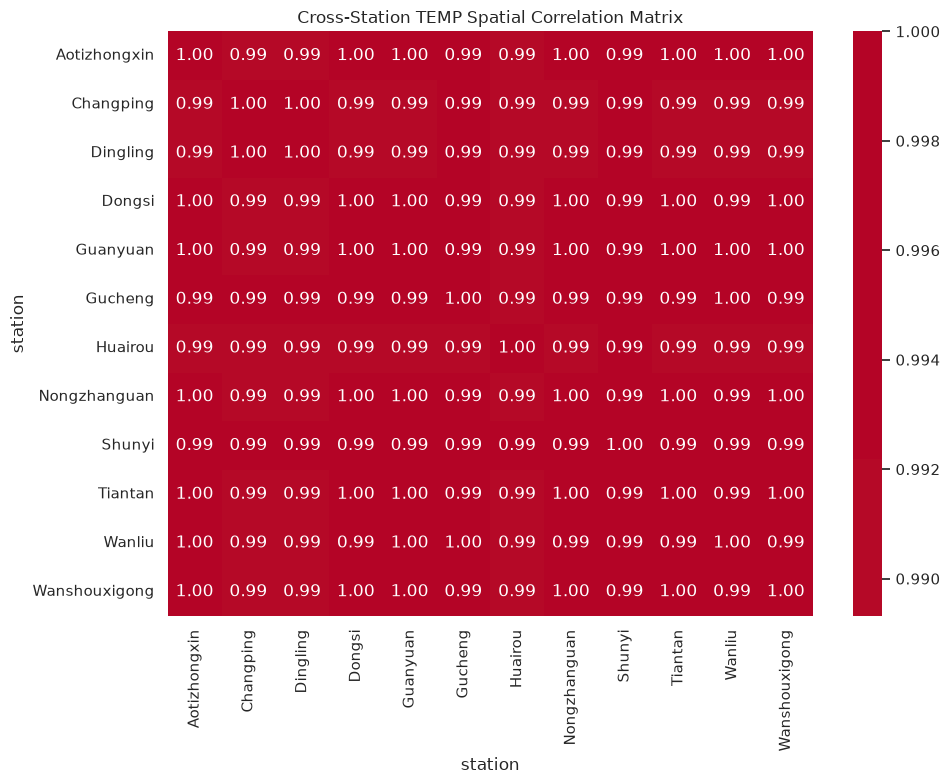

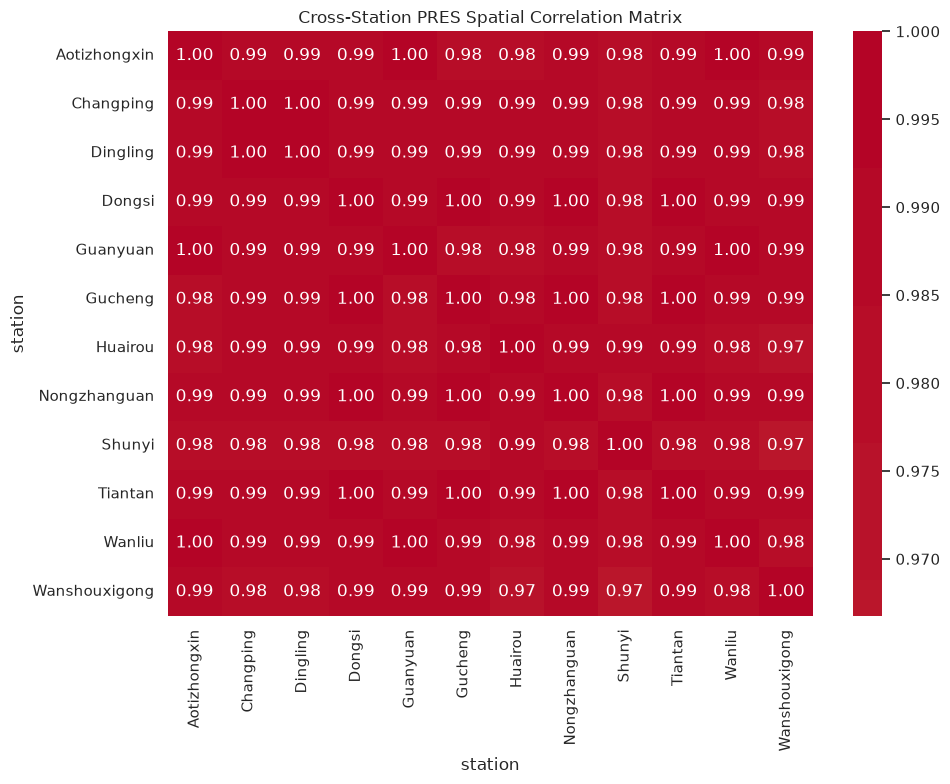

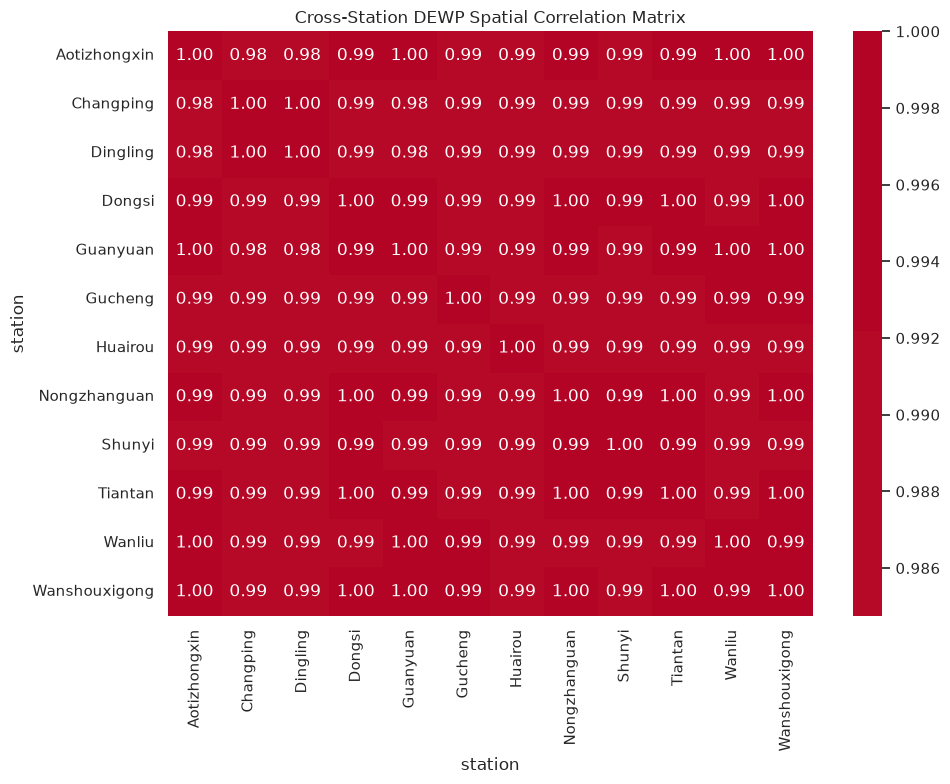

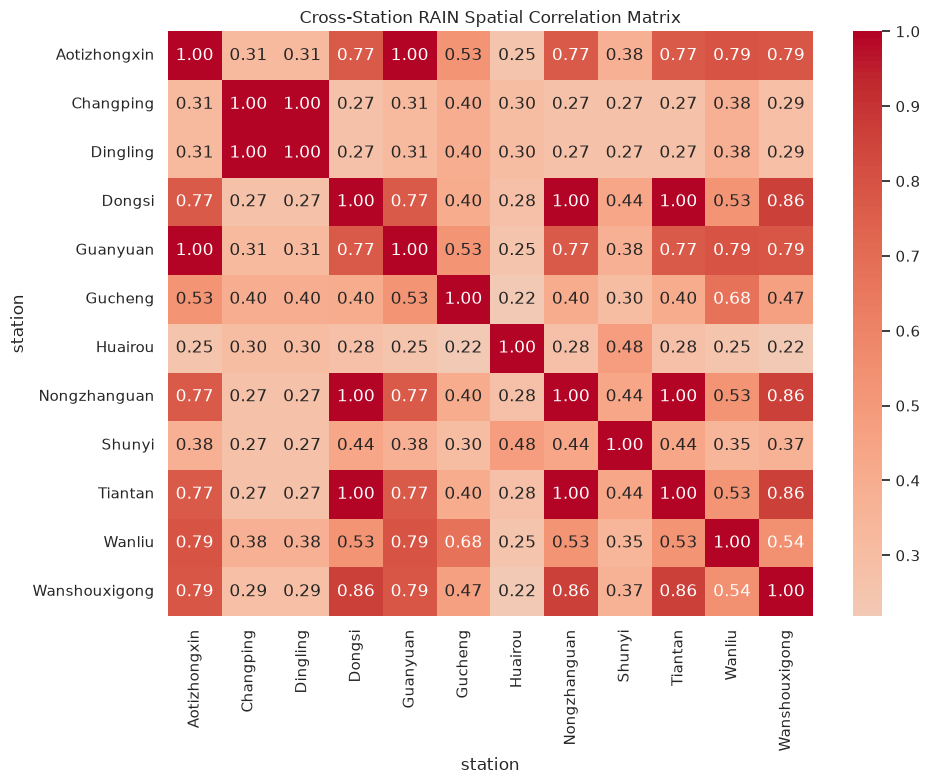

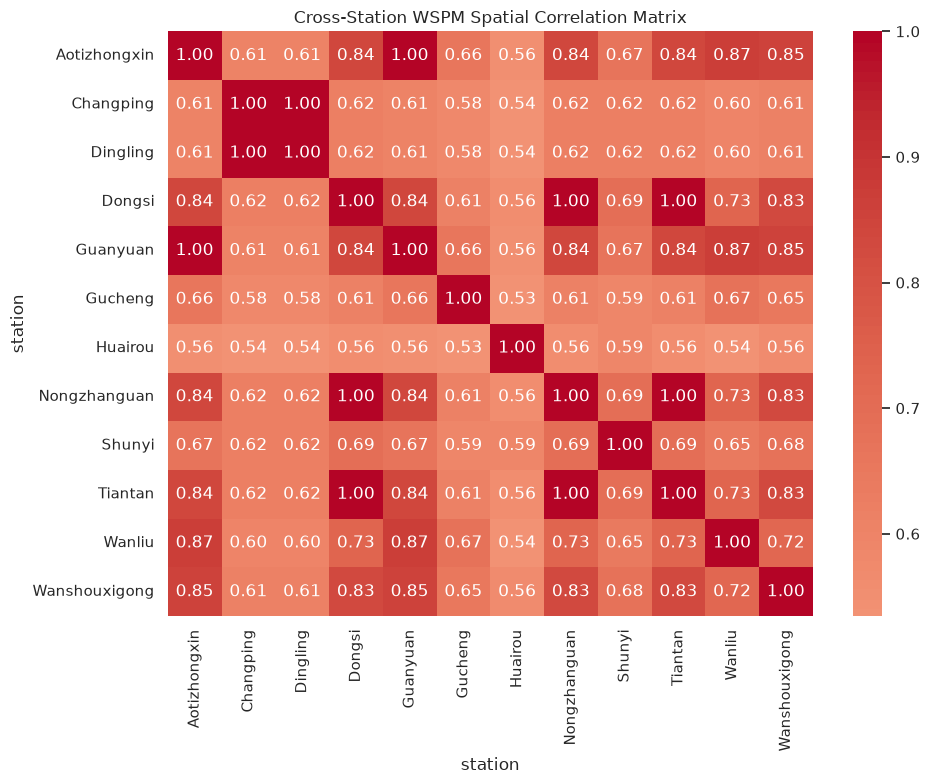

In [21]:
for col in NUMERIC_COLS:
    pivoted = df.pivot(index='datetime', columns='station', values=col)
    station_pm25_corr = pivoted.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(station_pm25_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title(f'Cross-Station {col} Spatial Correlation Matrix')
    plt.tight_layout()
    plt.title(f'Cross-Station {col} Spatial Correlation Matrix')
    fig.savefig(os.path.join(reports_dir, f"correlation_{col}_matrix.png"))

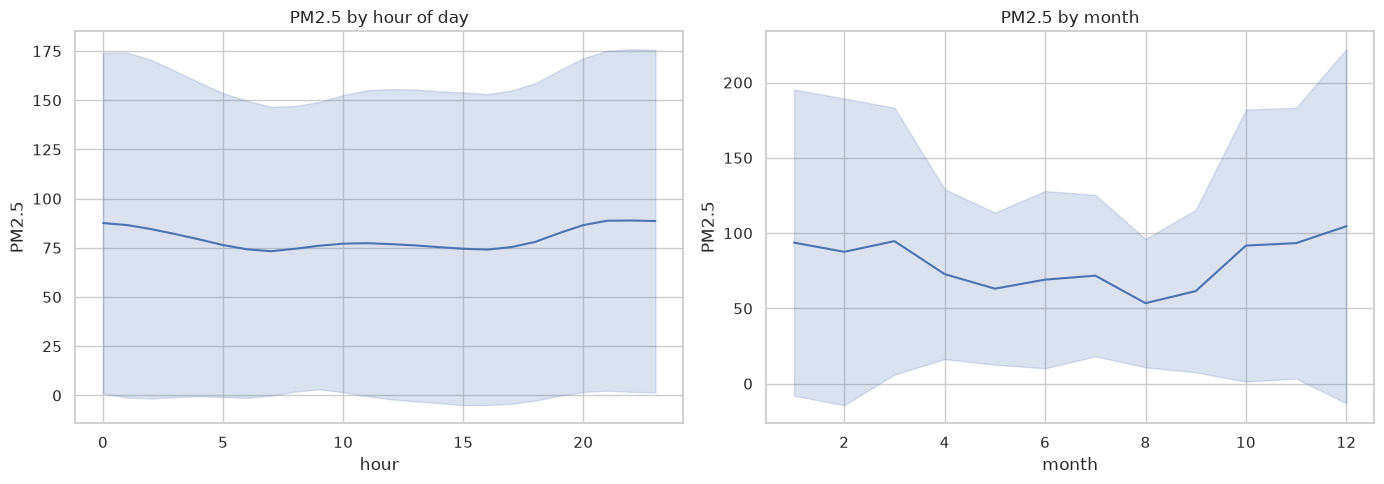

In [22]:
tmp = df.copy()
tmp["hour"] = tmp["datetime"].dt.hour
tmp["month"] = tmp["datetime"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=tmp, x="hour", y=TARGET[0], ax=axes[0], errorbar="sd")
axes[0].set_title(f"PM2.5 by hour of day")
sns.lineplot(data=tmp, x="month", y=TARGET[0], ax=axes[1], errorbar="sd")
axes[1].set_title(f"PM2.5 by month")
plt.tight_layout()
fig.savefig(os.path.join(reports_dir, "temporal_patterns.png"))

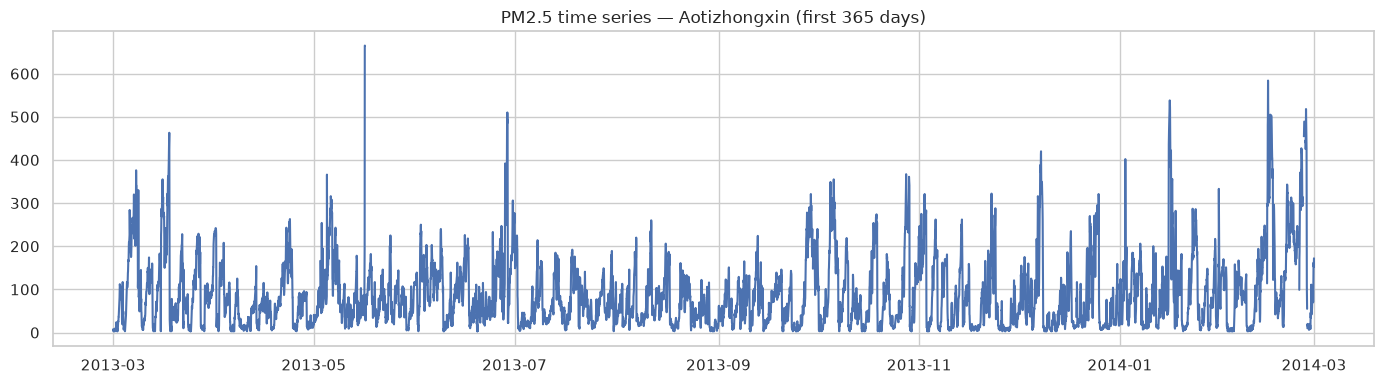

In [23]:
example_station = df["station"].unique()[0]
ex = df[df["station"] == example_station].head(24 * 365)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ex["datetime"], ex[TARGET[0]])
ax.set_title(f"{TARGET[0]} time series — {example_station} (first 365 days)")
plt.tight_layout()
fig.savefig(os.path.join(reports_dir, "example_series.png"))

# Check relationship between wind speed and wind direction missingness

In [24]:
# Get wind speed value when wind direction is missing
wspd_when_wdir_missing = df.loc[df[WIND_DIR_COL].isna(), "WSPM"]
wspd_when_wdir_missing.describe()


count    1504.000000
mean        0.215426
std         0.592345
min         0.000000
25%         0.000000
50%         0.100000
75%         0.200000
max         6.500000
Name: WSPM, dtype: float64

In [25]:
df["WSPM"].describe()

count    420450.000000
mean          1.729711
std           1.246386
min           0.000000
25%           0.900000
50%           1.400000
75%           2.200000
max          13.200000
Name: WSPM, dtype: float64

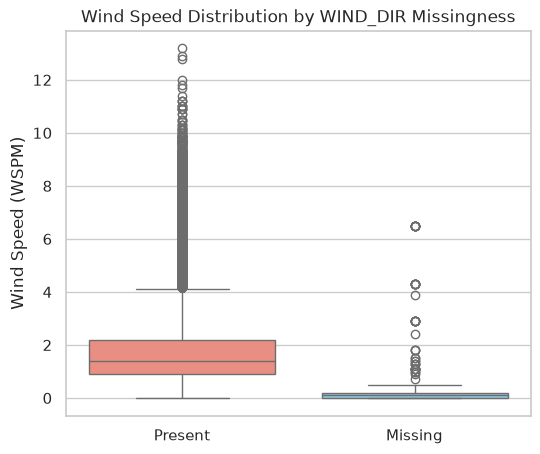

In [26]:
df["wdir_missing"] = df[WIND_DIR_COL].isna().map({True: "Missing", False: "Present"})

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="wdir_missing", y="WSPM", palette=["salmon", "skyblue"])
plt.title("Wind Speed Distribution by WIND_DIR Missingness")
plt.xlabel("")
plt.ylabel("Wind Speed (WSPM)")
plt.show()

# Clean missing data

In [27]:
# Numeric columns excepts rain and wind speed
COLS_TO_FILL_WITH_OTHER_STATIONS = [col for col in NUMERIC_COLS if col not in ["RAIN", "WSPM"]]
for col in COLS_TO_FILL_WITH_OTHER_STATIONS:
    pivot = df.pivot(index='datetime', columns='station', values=col)
    row_sum = pivot.sum(axis=1)
    row_count = pivot.notna().sum(axis=1)

    other_sum = row_sum.values[:, None] - pivot.fillna(0).values
    own_present = pivot.notna().values
    other_count = row_count.values[:, None] - own_present.astype(int)

    with np.errstate(invalid="ignore", divide="ignore"):
        other_mean = other_sum / other_count
    other_mean = pd.DataFrame(other_mean, index=pivot.index, columns=pivot.columns)

    pivot = pivot.where(pivot.notna(), other_mean)

    # linear interpolation for remaining missing values
    pivot = pivot.interpolate(method="linear", limit_direction="both")

    filled = pivot.stack().rename(col)
    df = df.drop(columns=[col]).merge(
        filled.reset_index(), on=["datetime", "station"], how="left"
    )


In [28]:
COLS_TO_FILL_WITH_INTERPOLATION = ["RAIN", "WSPM"]
for col in COLS_TO_FILL_WITH_INTERPOLATION:
    pivot = df.pivot(index='datetime', columns='station', values=col)
    pivot = pivot.interpolate(method="linear", limit_direction="both")
    filled = pivot.stack().rename(col)
    df = df.drop(columns=[col]).merge(
        filled.reset_index(), on=["datetime", "station"], how="left"
    )

In [29]:
# Handle missing wd by backward and forward filling
df['wd'] = df['wd'].bfill().ffill()

# Handle extreme outliers

In [30]:
for col in POLLUTANTS + ["WSPM"]:
    df[col] = df[col].clip(lower=0)

# winsorize extreme tails per column (global, not per-station)
for col in NUMERIC_COLS:
    lo, hi = df[col].quantile([0.001, 0.999])
    df[col] = df[col].clip(lower=lo, upper=hi)

# Auto-Correlation

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

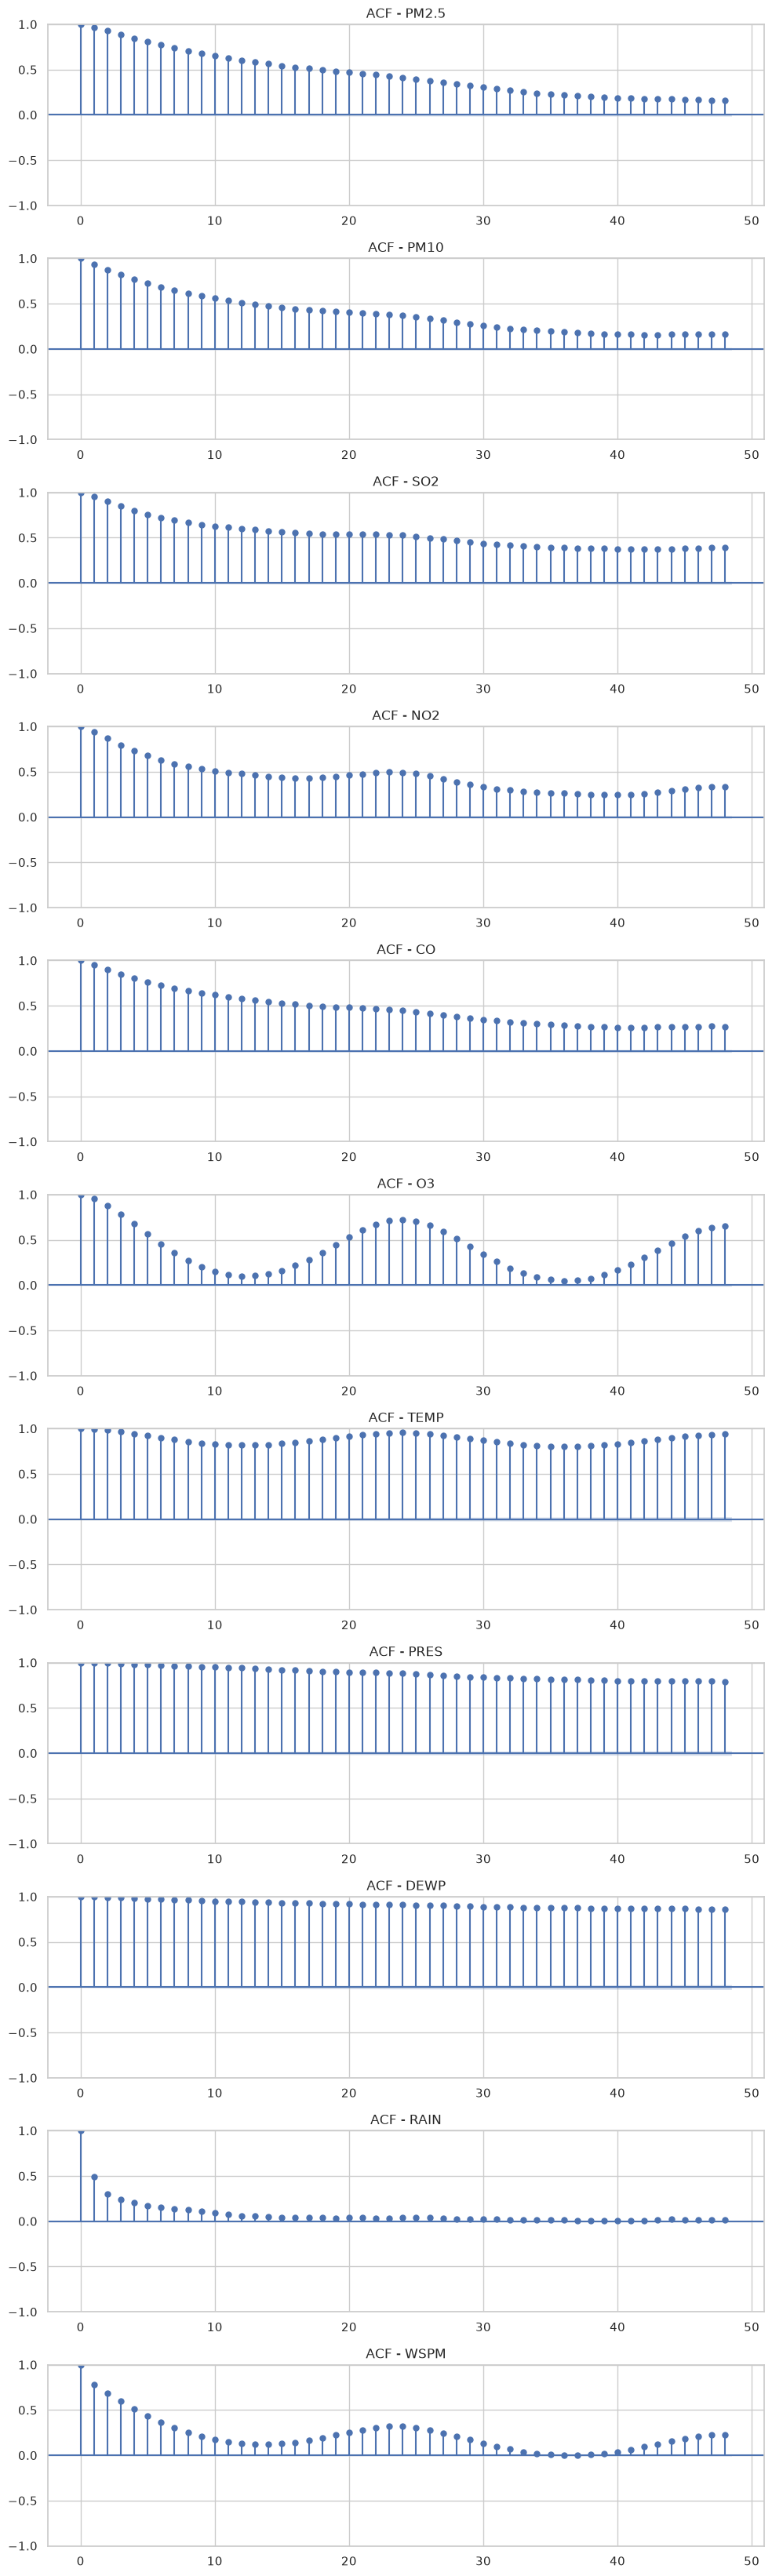

In [32]:


fig, axes = plt.subplots(len(NUMERIC_COLS), 1, figsize=(10, 3*len(NUMERIC_COLS)))

for ax, col in zip(axes, NUMERIC_COLS):
    plot_acf(df[col].dropna(), lags=48, ax=ax)
    ax.set_title(f"ACF - {col}")

plt.tight_layout()
plt.show()

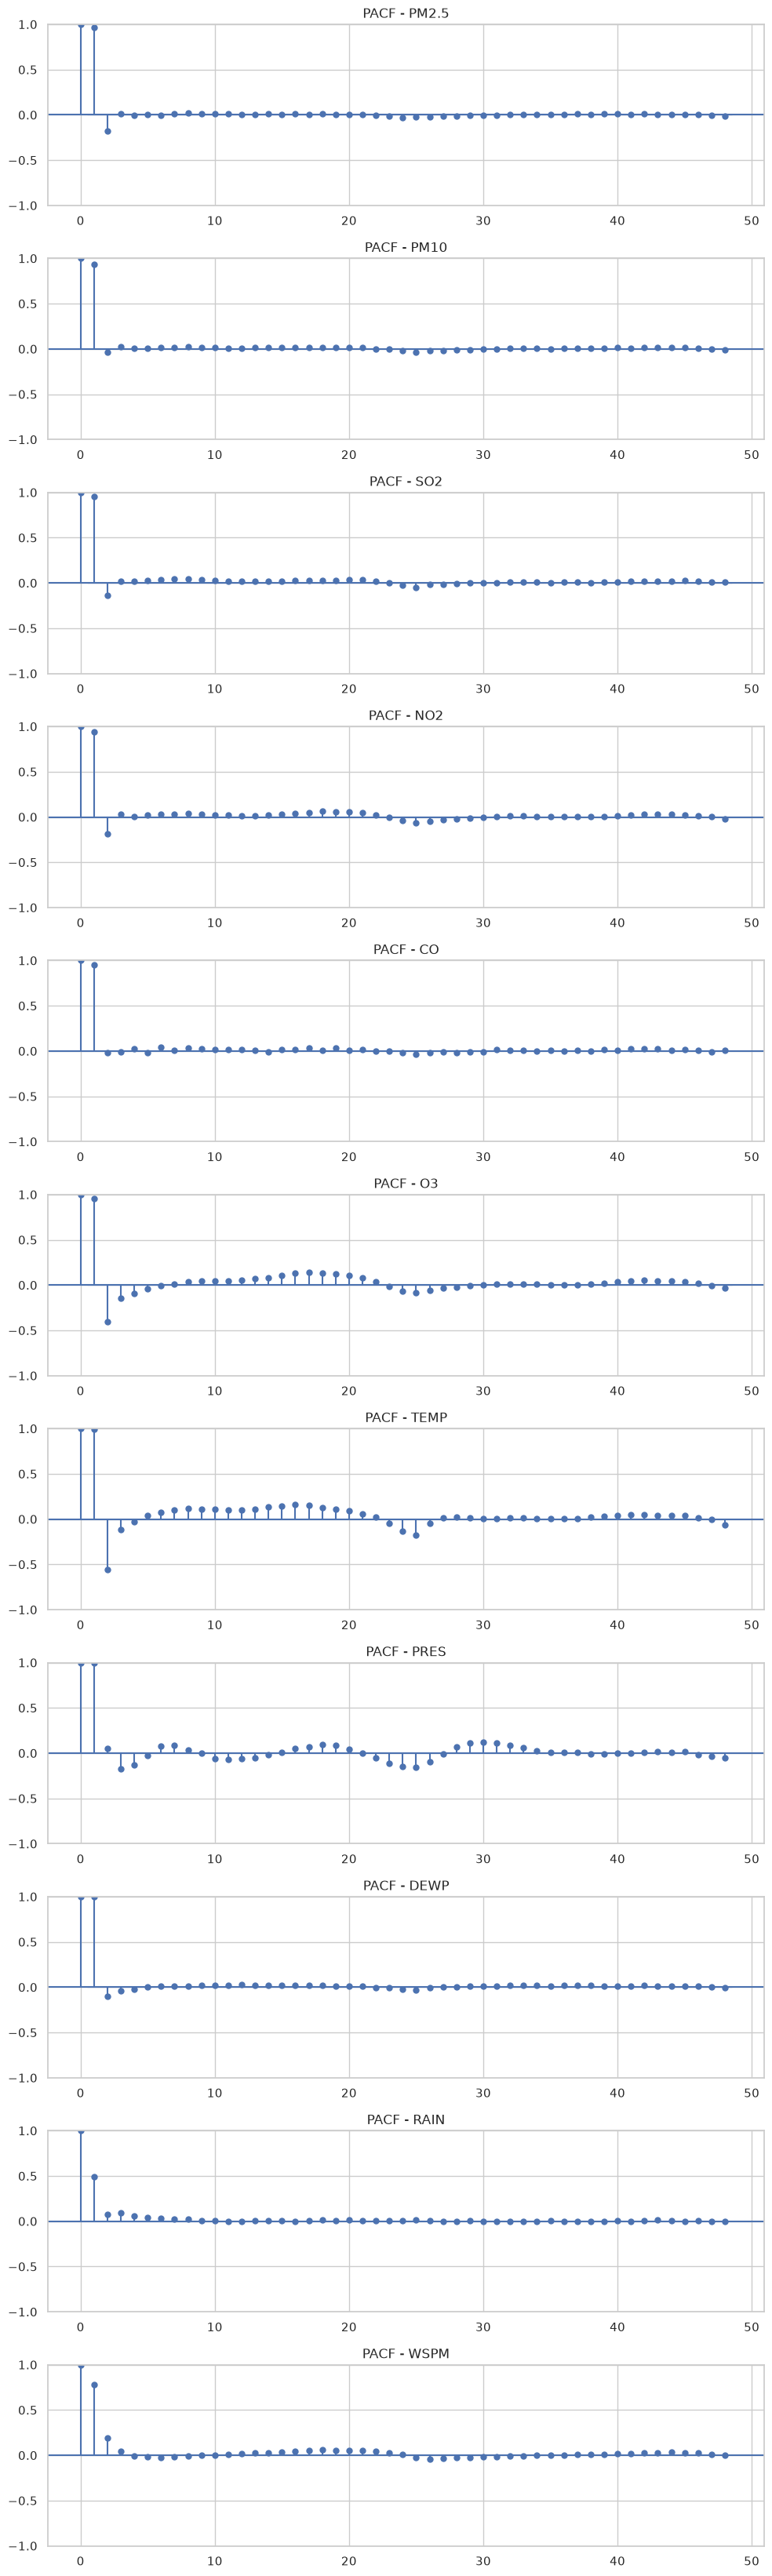

In [33]:
fig, axes = plt.subplots(len(NUMERIC_COLS), 1, figsize=(10, 3*len(NUMERIC_COLS)))

for ax, col in zip(axes, NUMERIC_COLS):
    plot_pacf(df[col].dropna(), lags=48, ax=ax)
    ax.set_title(f"PACF - {col}")

plt.tight_layout()
plt.show()

# Feature Engineering

In [34]:
df["hour_sin"] = np.sin(2 * np.pi * df["datetime"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["datetime"].dt.hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["datetime"].dt.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["datetime"].dt.dayofweek / 7)
df["month_sin"] = np.sin(2 * np.pi * df["datetime"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["datetime"].dt.month / 12)

wd_dummies = pd.get_dummies(df[WIND_DIR_COL], prefix="wd")
station_dummies = pd.get_dummies(df["station"], prefix="station")

df = pd.concat([df, wd_dummies, station_dummies], axis=1)

# Splitting Data

In [35]:
train_df = df[df["datetime"] <= TRAIN_END]
val_df = df[(df["datetime"] > TRAIN_END) & (df["datetime"] <= VAL_END)]
test_df = df[df["datetime"] > VAL_END]
print(f"   train: {train_df['datetime'].min()} -> {train_df['datetime'].max()} "
        f"({len(train_df)} rows)")
print(f"   val:   {val_df['datetime'].min()} -> {val_df['datetime'].max()} "
        f"({len(val_df)} rows)")
print(f"   test:  {test_df['datetime'].min()} -> {test_df['datetime'].max()} "
        f"({len(test_df)} rows)")

   train: 2013-03-01 00:00:00 -> 2015-12-31 23:00:00 (298368 rows)
   val:   2016-01-01 00:00:00 -> 2016-12-31 23:00:00 (105408 rows)
   test:  2017-01-01 00:00:00 -> 2017-02-28 23:00:00 (16992 rows)


# Apply scaling and fitting & build training window for each data point

In [36]:
def fit_scalers(train_df: pd.DataFrame, feature_cols: list, target_cols: list):
    feat_scaler = StandardScaler().fit(train_df[feature_cols])
    target_scaler = StandardScaler().fit(train_df[target_cols])
    return feat_scaler, target_scaler

In [37]:
def apply_scaling(df: pd.DataFrame, feature_cols, target_cols,
                   feat_scaler, target_scaler) -> pd.DataFrame:
    df = df.copy()
    df[feature_cols] = feat_scaler.transform(df[feature_cols])
    # target columns are also inputs (e.g. PM2.5 history is a feature),
    # so keep a separately-scaled copy for building y windows
    scaled_targets = target_scaler.transform(df[target_cols])
    for i, c in enumerate(target_cols):
        df[c + "_scaled_target"] = scaled_targets[:, i]
    return df

In [38]:
def build_windows(df: pd.DataFrame, feature_cols, target_cols,
                   input_len=INPUT_LEN, output_len=OUTPUT_LEN):
    
    target_scaled_cols = [c + "_scaled_target" for c in target_cols]

    X_all, y_all, meta_all = [], [], []
    for station, g in df.groupby("station"):
        g = g.sort_values("datetime").reset_index(drop=True)
        feats = g[feature_cols].to_numpy(dtype=np.float32)
        targs = g[target_scaled_cols].to_numpy(dtype=np.float32)
        times = g["datetime"].to_numpy()

        n = len(g)
        total_len = input_len + output_len
        for start in range(0, n - total_len + 1):
            X_all.append(feats[start: start + input_len])
            y_all.append(targs[start + input_len: start + total_len])
            meta_all.append((station, times[start], times[start + input_len]))

        print(f"   {station:15s} -> {max(0, n - total_len + 1):6d} windows")

    X = np.stack(X_all).astype(np.float32)
    y = np.stack(y_all).astype(np.float32)
    meta = np.array(meta_all, dtype=object)
    print(f"   total windows: X={X.shape}, y={y.shape}")
    return X, y, meta

In [39]:
df.dtypes

wd                                  str
station                             str
datetime                 datetime64[us]
wdir_missing                        str
PM2.5                           float64
PM10                            float64
SO2                             float64
NO2                             float64
CO                              float64
O3                              float64
TEMP                            float64
PRES                            float64
DEWP                            float64
RAIN                            float64
WSPM                            float64
hour_sin                        float64
hour_cos                        float64
dow_sin                         float64
dow_cos                         float64
month_sin                       float64
month_cos                       float64
wd_E                               bool
wd_ENE                             bool
wd_ESE                             bool
wd_N                               bool


In [43]:
exclude = {"datetime", "station", "wd", "wdir_missing"}

feature_cols = [c for c in df.columns if c not in exclude]
target_cols = TARGET

feat_scaler, target_scaler = fit_scalers(train_df, feature_cols, target_cols)
train_df = apply_scaling(train_df, feature_cols, target_cols, feat_scaler, target_scaler)
val_df = apply_scaling(val_df, feature_cols, target_cols, feat_scaler, target_scaler)
test_df = apply_scaling(test_df, feature_cols, target_cols, feat_scaler, target_scaler)

In [49]:
X_train, y_train, meta_train = build_windows(train_df, feature_cols, target_cols)
X_val, y_val, meta_val = build_windows(val_df, feature_cols, target_cols)
X_test, y_test, meta_test = build_windows(test_df, feature_cols, target_cols)

   Aotizhongxin    ->  24817 windows
   Changping       ->  24817 windows
   Dingling        ->  24817 windows
   Dongsi          ->  24817 windows
   Guanyuan        ->  24817 windows
   Gucheng         ->  24817 windows
   Huairou         ->  24817 windows
   Nongzhanguan    ->  24817 windows
   Shunyi          ->  24817 windows
   Tiantan         ->  24817 windows
   Wanliu          ->  24817 windows
   Wanshouxigong   ->  24817 windows
   total windows: X=(297804, 24, 45), y=(297804, 24, 1)
   Aotizhongxin    ->   8737 windows
   Changping       ->   8737 windows
   Dingling        ->   8737 windows
   Dongsi          ->   8737 windows
   Guanyuan        ->   8737 windows
   Gucheng         ->   8737 windows
   Huairou         ->   8737 windows
   Nongzhanguan    ->   8737 windows
   Shunyi          ->   8737 windows
   Tiantan         ->   8737 windows
   Wanliu          ->   8737 windows
   Wanshouxigong   ->   8737 windows
   total windows: X=(104844, 24, 45), y=(104844, 24, 1)


In [52]:
np.savez_compressed(os.path.join(output_dir, "train_windows.npz"),
                         X=X_train, y=y_train, meta=meta_train)
np.savez_compressed(os.path.join(output_dir, "val_windows.npz"),
                        X=X_val, y=y_val, meta=meta_val)
np.savez_compressed(os.path.join(output_dir, "test_windows.npz"),
                        X=X_test, y=y_test, meta=meta_test)

In [53]:
with open(os.path.join(output_dir, "feature_scaler.pkl"), "wb") as f:
        pickle.dump(feat_scaler, f)
with open(os.path.join(output_dir, "target_scaler.pkl"), "wb") as f:
    pickle.dump(target_scaler, f)
with open(os.path.join(output_dir, "feature_columns.json"), "w") as f:
    json.dump({"feature_cols": feature_cols, "target_cols": target_cols}, f, indent=2)